<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification-fatigue-detection/blob/main/Deteccao_Sonolencia_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando dependências necessárias

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ConvNeXtLarge
from tensorflow.keras import layers, Model, regularizers
import kagglehub
import shap

Carregando dataset

In [3]:
path = kagglehub.dataset_download("serenaraju/yawn-eye-dataset-new")

print("Path to dataset files:", path)

Path to dataset files: /home/usuario/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1


In [4]:
path = "/home/usuario/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1"

for item in os.listdir(path):
    print(item)

dataset_new


In [5]:
BASE = "/home/usuario/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new"

train_dir = os.path.join(BASE, "train")
test_dir  = os.path.join(BASE, "test")

print(train_dir)
print(test_dir)

CLASSES = sorted(os.listdir(train_dir))
NUM_CLASSES = len(CLASSES)
print("Classes:", CLASSES)

/home/usuario/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/train
/home/usuario/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/test
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']


In [6]:
IMAGE_SIZE = 256

def carregar_dataset_np(root):
    imagens = []
    rotulos = []

    for label, cls in enumerate(CLASSES):
        cls_path = os.path.join(root, cls)

        for fname in os.listdir(cls_path):
            if fname.lower().endswith(("jpg","png","jpeg")):
                img_path = os.path.join(cls_path, fname)

                img = Image.open(img_path).convert("RGB")
                img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

                img = np.array(img, dtype=np.float32) / 255.0

                imagens.append(img)
                rotulos.append(label)

    return np.array(imagens), np.array(rotulos)

Treinando dataset

In [55]:
X_train, y_train = carregar_dataset_np(train_dir)
X_test,  y_test  = carregar_dataset_np(test_dir)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

: 

In [8]:
BATCH = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(2000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

E0000 00:00:1778189313.347189    7197 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1778189313.349814    7197 cpu_allocator_impl.cc:82] Allocation of 1940127744 exceeds 10% of free system memory.


W0000 00:00:1778188967.092448    5499 cpu_allocator_impl.cc:82] Allocation of 1940127744 exceeds 10% of free system memory.


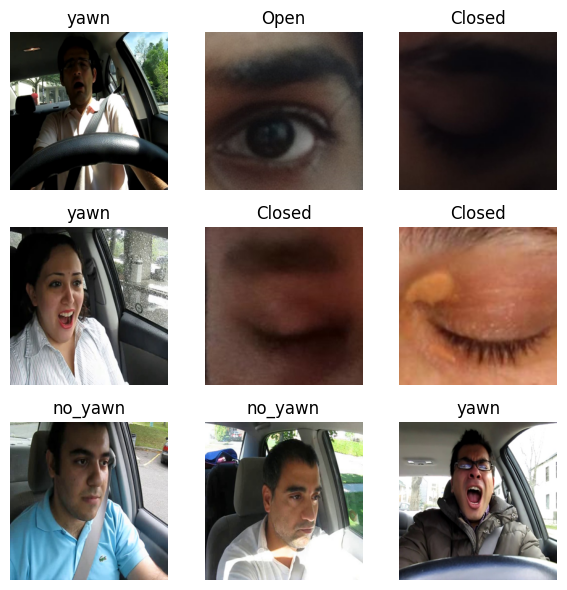

In [8]:
plt.figure(figsize=(6,6))
for i, (img, label) in enumerate(train_ds.unbatch().take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(img.numpy())
    plt.title(CLASSES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:

modelo = keras.Sequential([
    keras.Input(shape = (IMAGE_SIZE, IMAGE_SIZE, 3)),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       984,068 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,003,460 (3.83 MB)

 Trainable params: 1,003,460 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)

In [11]:
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = modelo.fit(train_ds,
                     validation_data=test_ds,
                     epochs=10)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.6818 - loss: 1.1190 - val_accuracy: 0.8083 - val_loss: 0.6267
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8577 - loss: 0.5406 - val_accuracy: 0.9007 - val_loss: 0.4688
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9060 - loss: 0.4178 - val_accuracy: 0.8730 - val_loss: 0.4285
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9493 - loss: 0.3249 - val_accuracy: 0.8684 - val_loss: 0.4437
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9647 - loss: 0.2639 - val_accuracy: 0.9353 - val_loss: 0.3182
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9655 - loss: 0.2500 - val_accuracy: 0.9400 - val_loss: 0.3025
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9757 - loss: 0.2111 - val_accuracy: 0.9400 - val_loss: 0.3221
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9846 - loss: 0.1764 - val_accuracy: 0.9561 

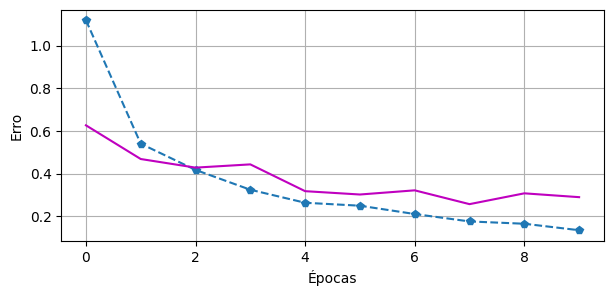

In [12]:
plt.figure(figsize=(7,3))
plt.plot(history.history['loss'], 'p--', label='Perda treino')
plt.plot(history.history['val_loss'], 'm', label ='Perda validade')
plt.ylabel('Erro')
plt.xlabel('Épocas')
plt.grid(True)

In [13]:
from sklearn.metrics import classification_report

y_true = y_test

y_pred_proba = modelo.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASSES))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
              precision    recall  f1-score   support

      Closed       0.92      0.96      0.94       109
        Open       0.96      0.92      0.94       109
     no_yawn       0.88      0.97      0.93       109
        yawn       0.97      0.87      0.92       106

    accuracy                           0.93       433
   macro avg       0.93      0.93      0.93       433
weighted avg       0.93      0.93      0.93       433



In [14]:
modelo.save('modelo_cnn_YE.h5')
modelo.save('modelo_cnn_YE.keras')

modelo.save_weights('modelo_cnn_YE.weights.h5')

In [49]:
# load model — recria a arquitetura e carrega os pesos do .h5
modelo = keras.Sequential([
    keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
modelo.load_weights('modelo_cnn_YE.h5')
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       984,068 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,003,460 (3.83 MB)

 Trainable params: 1,003,460 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
N_EXPLAIN = 10

# GradientExplainer e DeepExplainer têm bugs com Keras 3 (gradientes zerados).
# Usamos SHAP via tf.GradientTape diretamente, que é equivalente ao Expected Gradients.

background = X_train[np.random.choice(X_train.shape[0], 50, replace=False)]
classes_teste = np.unique(y_test[:N_EXPLAIN])


def expected_gradients_shap(model, inputs, background, n_samples=20):
    """Calcula Expected Gradients (base do DeepExplainer) manualmente via GradientTape."""
    inputs_tensor = tf.cast(inputs, tf.float32)
    shap_maps = []
    for img in inputs_tensor:
        img = tf.expand_dims(img, 0)  # (1, H, W, C)
        # Escolher n_samples aleatórias do background
        idx = np.random.choice(len(background), min(n_samples, len(background)), replace=False)
        bg_samples = tf.cast(background[idx], tf.float32)
        grads_accum = tf.zeros_like(img)  # (1, H, W, C)
        for bg in bg_samples:
            bg = tf.expand_dims(bg, 0)  # (1, H, W, C)
            alpha = tf.random.uniform([], 0.0, 1.0)
            interpolated = bg + alpha * (img - bg)
            with tf.GradientTape() as tape:
                tape.watch(interpolated)
                preds = model(interpolated, training=False)
                pred_class = tf.argmax(preds[0]).numpy()
                score = preds[:, pred_class]
            grad = tape.gradient(score, interpolated)  # (1, H, W, C)
            grads_accum += grad * (img - bg)
        shap_maps.append((grads_accum / n_samples).numpy()[0])  # (H, W, C)
    return np.array(shap_maps), pred_class  # (N, H, W, C)

shap_maps, _ = expected_gradients_shap(modelo, X_test[:N_EXPLAIN], background)
print("SHAP maps shape:", shap_maps.shape)
print("Min/Max:", shap_maps.min(), shap_maps.max())

SHAP maps shape: (10, 256, 256, 3)
Min/Max: -0.0017682668 0.00187707


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


/tmp/ipykernel_7197/4168241556.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


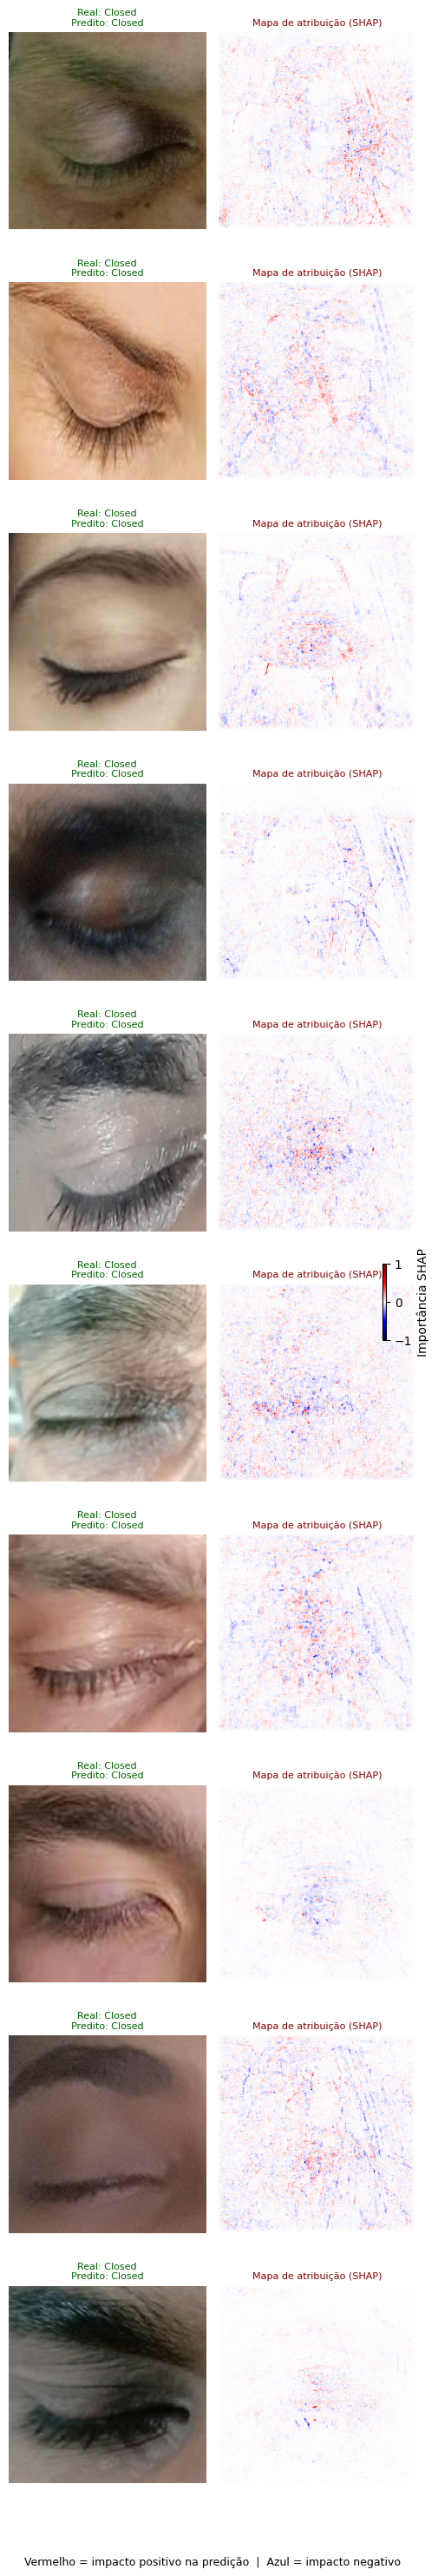

In [ ]:
# Predições
y_pred_proba = modelo.predict(X_test[:N_EXPLAIN])
y_pred_local = np.argmax(y_pred_proba, axis=1)

# Normalizar simetricamente para [-1, 1] preservando sinal
def normalizar_simetrico(arr, eps=1e-8):
    return np.array([v / (np.abs(v).max() + eps) for v in arr])

shap_norm = normalizar_simetrico(shap_maps)


fig, axes = plt.subplots(N_EXPLAIN, 2, figsize=(5, N_EXPLAIN * 3))
for i in range(N_EXPLAIN):
    correct = y_test[i] == y_pred_local[i]
    color = 'darkgreen' if correct else 'crimson'
    axes[i, 0].imshow(X_test[i])
    axes[i, 0].set_title(
        f"Real: {CLASSES[y_test[i]]}\nPredito: {CLASSES[y_pred_local[i]]}",
        fontsize=8, color=color
    )
    axes[i, 0].axis('off')

    # Média dos canais RGB
    shap_map = shap_norm[i].mean(axis=-1)

    im = axes[i, 1].imshow(shap_map, cmap='seismic', vmin=-1, vmax=1)
    axes[i, 1].set_title('Mapa de atribuição (SHAP)', fontsize=8, color='darkred')
    axes[i, 1].axis('off')

fig.colorbar(im, ax=axes[:, 1], fraction=0.025, pad=0.04, label='Importância SHAP')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()
